## Loading the Dataset

In [49]:
# parsing metadata
import gzip
from pathlib import Path

scr =  Path("../data/raw/GSE122198_family.soft.gz")
metadata = {}
with gzip.open(scr, "rt") as f:
    current_sample = None
    for line in f:
        if line.startswith("^SAMPLE"):
            current_sample = line.strip().split(" = ")[1]
            metadata[current_sample] = {}
        elif line.startswith("!Sample_") and current_sample:
            key, val = line.strip().split(" = ", 1)
            metadata[current_sample][key] = val

In [50]:
import scanpy as sc
import pandas as pd
import anndata as ad

# loading data into scanpy using anndata
df = Path("../data/raw/GSE122198_Rodriguez-Meira_et.al_3TARGET_counts.txt")
adata = sc.read_csv(df, delimiter="\t", first_column_names=True).T

adata.obs_names_make_unique()
adata.var_names_make_unique()

adata

/home/ace/miniconda3/envs/jak2/lib/python3.14/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/ace/miniconda3/envs/jak2/lib/python3.14/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 2798 × 23802

## Quality control

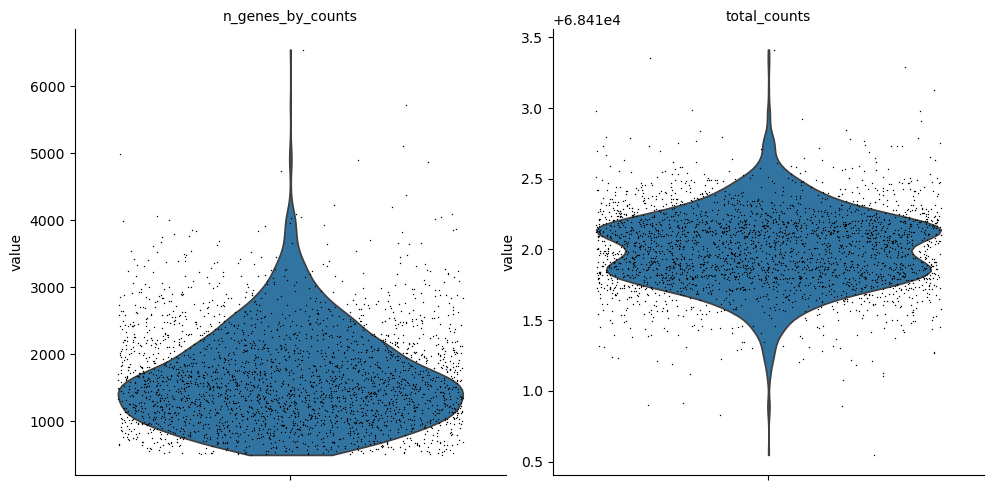

In [51]:

# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(adata, inplace=True)
sc.pl.violin(adata, ["n_genes_by_counts", "total_counts"], jitter=0.4, multi_panel=True)


In [52]:

# Filtering cells
# Only filtering cells with less than 100 genes expressed and genes that are detected in less than 3 cells.
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

# Doublet detection using scrublet
sc.pp.scrublet(adata)

In [53]:
# Normalizing data
# save raw counts in a layer
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)

# Log-transform the data
sc.pp.log1p(adata)

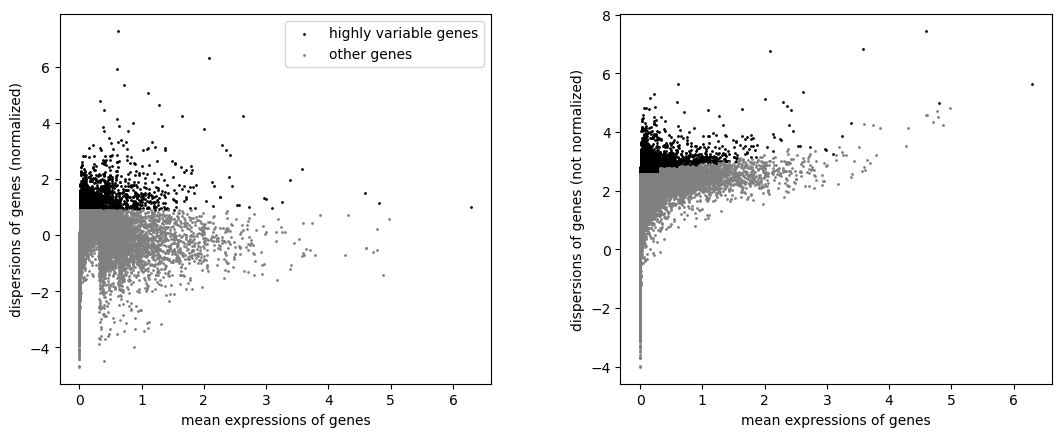

In [54]:
# Feature selection
# identifying most informative genes 

sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.pl.highly_variable_genes(adata)

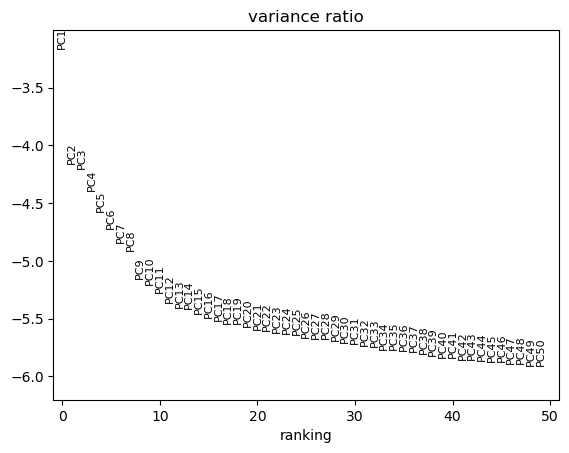

In [55]:
# Dimensionality reduction

# Running PCA
sc.pp.pca(adata, mask_var="highly_variable")

# Inspecting the variance explained by each principal component
# Gives info about how many PCs to use for downstream analysis
# Overestimating the number of PCs can lead to noise, while underestimating can lead to loss of important biological signal.
# Usually better to overestimate then find optimal number of PCs later
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

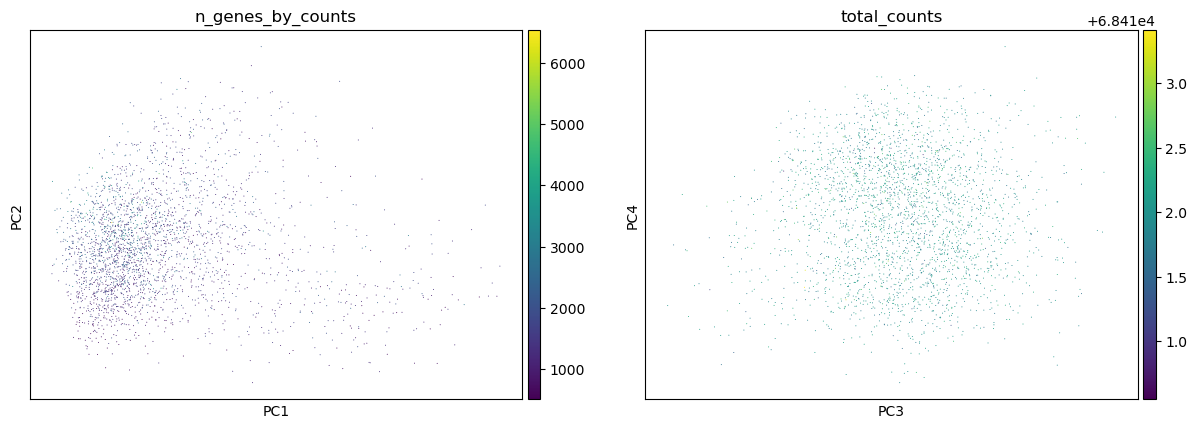

In [56]:
# Plotting the PCs to visualize the data structure
sc.pl.pca(
    adata,
    color=["n_genes_by_counts", "total_counts"],
    dimensions=[(0, 1), (2, 3)],
    ncols=2,
    size=2,
)